# Гипотеза: Prefix Dropout для Semantic IDs (RQ 2)

Идея: при обучении seqrec случайно обрезать Semantic ID некоторых треков
до первых ` кодов (выкинуть хвост и unique-токен). Модель вынуждена обобщать
по семантике префикса и, следовательно, лучше работает с редкими треками.

## Как это работает

SID трека = `[код₁, код₂, код₃, UNIQUE]`

| Режим | Что видит модель | Суть |
|-------|-----------------|------|
| Без дропаута | `[код₁, код₂, код₃, UNIQUE]` | Точная идентификация трека |
| С дропаутом (keep=1) | `[код₁]` | Только самый грубый уровень (≈ жанр/артист) |
| С дропаутом (keep=2) | `[код₁, код₂]` | Средний уровень (≈ артист+альбом) |

- `prefix_dropout_prob=0.2` — 20% треков в истории обрезаются
- `prefix_dropout_keep=1` — оставляем 1 код 
- UNIQUE-токен выбрасывается
- тест не трогается

## A/B эксперимент

Берём одни и те же SID (`original/sids.parquet`) и обучаем seqrec дважды:
1. Baseline: стандартный `seqrec_original.yaml`
2. Dropout:`seqrec_prefix_dropout.yaml` 

Разница в метриках = эффект дропаута.

---

## pipeline блокнота


1. Скачать данные Yambda (HuggingFace)        
2. Препроцессинг (build_yambda_subset)        
3. Метаданные артист/альбом                   
4. Обучить dVAE original       ~1.5 ч на A100
5. Обучить seqrec с prefix dropout             ~30-60 мин на A100
6. Сравнить с baseline


---
## 0. Проверка окружения

In [ ]:
import os, sys, json
import torch
import polars as pl
from scripts.data.yambda import download_metadata


if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working dir:", os.getcwd())
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU не найден")

Working dir: /home/jupyter/project/semantic_ids
Python: 3.10.12 (main, Jun 11 2023, 05:26:28) [GCC 11.4.0]
PyTorch: 2.0.1+cu118
CUDA available: True
GPU: NVIDIA L4


---
## 1. качаем данные Yambda

Скачиваем с HuggingFace:
- interactions.parquet — история прослушиваний
- embeddings.parquet — эмбеддинги треков
- artist_item_mapping.parquet — маппинг трек - артист
- album_item_mapping.parquet — маппинг трек - альбом

In [ ]:
RAW_DATA_DIR = "./data/yambda"

needed_raw = ["interactions.parquet", "embeddings.parquet",
              "artist_item_mapping.parquet", "album_item_mapping.parquet"]
missing = [f for f in needed_raw if not os.path.exists(os.path.join(RAW_DATA_DIR, f))]

if not missing:
    print("данные скачаеы")
    for f in needed_raw:
        size_mb = os.path.getsize(os.path.join(RAW_DATA_DIR, f)) / 1e6
else:
    print(f"скачиваем: {missing}")

Скачиваем: ['interactions.parquet', 'embeddings.parquet', 'artist_item_mapping.parquet', 'album_item_mapping.parquet']


In [ ]:
%%time
from scripts.data.yambda import download
if not os.path.exists(os.path.join(RAW_DATA_DIR, "interactions.parquet")) or not os.path.exists(os.path.join(RAW_DATA_DIR, "embeddings.parquet")):
    download(dst_dir=RAW_DATA_DIR)


In [ ]:
%%time
if not os.path.exists(os.path.join(RAW_DATA_DIR, "artist_item_mapping.parquet")) or not os.path.exists(os.path.join(RAW_DATA_DIR, "album_item_mapping.parquet")):
    download_metadata(dst_dir=RAW_DATA_DIR)


---
## 2. Препроцессинг: build_yambda_subset

Строим из сырых данных подготовленный датасет:
- train/holdout/cold splits для dVAE
- train/test splits для seqrec
- эмбеддинги core-items

In [ ]:
%%time
PROJECT_DATA_DIR = "./data/RQ_album_artist_anchor/yambda"
!python3 -m scripts.RQ_album_artist_anchor.build_yambda_subset

---
## 3. Метаданные артист/альбом

Обогащает items файлы кластер-лейблами артиста/альбома.  
Нужно для prefix purity анализа.

In [ ]:
%%time
METADATA_FILE = os.path.join(PROJECT_DATA_DIR, "item_metadata_raw_dense_labels.parquet")
!python3 -m scripts.RQ_album_artist_anchor.build_artist_album_metadata


Строим artist/album метаданные...
✅ Метаданные построены
CPU times: user 44.4 ms, sys: 19 ms, total: 63.3 ms
Wall time: 11 s


---
## 4. Обучение dVAE 



генерируем semantic ids для всех трекв. 
Prefix dropout работает поверх этих SID 

In [ ]:
import torch.nn as nn
import torch

if not hasattr(nn, 'RMSNorm'):
    class RMSNorm(nn.Module):
        def __init__(self, d, eps=1e-5):
            super().__init__()
            self.weight = nn.Parameter(torch.ones(d))
            self.eps = eps
        def forward(self, x):
            return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight
    nn.RMSNorm = RMSNorm

if not hasattr(nn, 'Buffer'):
    nn.Buffer = lambda data, persistent=True: nn.Parameter(data, requires_grad=False)



In [ ]:
SIDS_PATH = "./results/RQ_album_artist_anchor/original/sids.parquet"
DVAE_CONFIG = "configs/RQ_album_artist_anchor/original_varlen_dvae.yaml"

if os.path.exists(SIDS_PATH):
    sids = pl.read_parquet(SIDS_PATH)


In [ ]:
%%time
import os, sys, yaml
import torch
from scripts.train_dvae import main

os.chdir(os.path.expanduser("~/project/semantic_ids"))

print("PyTorch:", torch.__version__, "CUDA:", torch.cuda.is_available())

with open("configs/RQ_album_artist_anchor/original_varlen_dvae.yaml") as f:
    cfg = yaml.safe_load(f)

main(cfg)



PyTorch: 2.0.1+cu118 CUDA: True


train(train_holdout): 100%|██████████| 48210/48210 [1:08:31<00:00, 11.73it/s, epoch=4, loss=1.11]


✅ dVAE done!
CPU times: user 1h 4min 30s, sys: 5min 54s, total: 1h 10min 24s
Wall time: 1h 8min 44s


---
## 5. Запуск seqrec с prefix dropout


train_seqrec_prefix_dropout.py
1. Строим данные стандартным пайплайном
2. Применяем prefix dropout к обучающим потокам
3. Обучаем seqrec
4. Оцениваем на тесте

In [4]:
import yaml

DROPOUT_CONFIG = "configs/RQ_album_artist_anchor/seqrec_prefix_dropout.yaml"
RESULT_DIR = "results/RQ_album_artist_anchor/prefix_dropout"

with open(DROPOUT_CONFIG) as f:
    cfg = yaml.safe_load(f)


In [ ]:
%%time
import os
import yaml
import torch
from scripts.train_seqrec import Graph

os.chdir(os.path.expanduser("~/project/semantic_ids"))


with open("configs/RQ_album_artist_anchor/seqrec_prefix_dropout.yaml") as f:
    cfg = yaml.safe_load(f)

# уменьшаем батч для 16 гб рам
cfg["train"]["device_batch_size"] = 64
cfg["train"]["ideal_batch_size_tokens"] = 16384
cfg["eval"]["max_batch_tokens"] = 8192
cfg["eval"]["max_batch_users"] = 128


def setup_optimizers_adamw(self, adam_lr, muon_lr, weight_decay):
    params = list(self.parameters())
    
    opt1 = torch.optim.AdamW(
        params,
        lr=adam_lr,
        betas=(0.65, 0.95),
        weight_decay=weight_decay,
    )
    
    opt2 = torch.optim.AdamW(
        [torch.nn.Parameter(torch.zeros(1))],
        lr=1e-9,
    )
    
    for opt in (opt1, opt2):
        for g in opt.param_groups:
            g["initial_lr"] = g["lr"]
    
    return [opt1, opt2]

Graph.setup_optimizers = setup_optimizers_adamw

from scripts.RQ_album_artist_anchor.train_seqrec_prefix_dropout import main
main(cfg)




Prefix dropout: p=0.2, keep=1
пользователей:812,012
токенов до:78,208,460
токенов после:65,309,950
выброшено:12,898,510 (16.5%)
Num training tokens: 65309950
Grad accum steps: 2
Total num steps: 4017


100%|██████████| 4016/4016 [06:33<00:00, 10.21it/s]
beam_search_batched: 277it [11:11,  2.42s/it]


  recall@10: 0.014359
  recall@50: 0.037921
  ndcg@10: 0.007174
  ndcg@50: 0.012232
  tail_recall@10: 0.000000
  tail_recall@50: 0.000197
  long_tail_share: 0.009755
  coverage@10: 0.012535
CPU times: user 20min 1s, sys: 27.9 s, total: 20min 29s
Wall time: 18min 58s


---
## 6. резы

In [9]:
import pandas as pd

BASELINE_RESULT = "results/RQ_album_artist_anchor/original/seqrec_summary.json"
DROPOUT_RESULT = f"{RESULT_DIR}/seqrec_summary.json"

with open(BASELINE_RESULT) as f:
    baseline = json.load(f)["metrics"]
with open(DROPOUT_RESULT) as f:
    dropout = json.load(f)["metrics"]



---
## 7.бейзлайн vs prefix dropout

In [ ]:
%%time
import os, yaml, torch
from scripts.train_seqrec import Graph
from scripts.train_seqrec import main
os.chdir(os.path.expanduser("~/project/semantic_ids"))

with open("configs/RQ_album_artist_anchor/seqrec_original.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["train"]["device_batch_size"] = 64
cfg["train"]["ideal_batch_size_tokens"] = 16384
cfg["eval"]["max_batch_tokens"] = 8192
cfg["eval"]["max_batch_users"] = 128
cfg["summary_json"] = "./results/RQ_album_artist_anchor/original_adamw/seqrec_summary.json"



def setup_optimizers_adamw(self, adam_lr, muon_lr, weight_decay):
    params = list(self.parameters())
    opt1 = torch.optim.AdamW(params, lr=adam_lr, betas=(0.65, 0.95), weight_decay=weight_decay)
    opt2 = torch.optim.AdamW([torch.nn.Parameter(torch.zeros(1))], lr=1e-9)
    for opt in (opt1, opt2):
        for g in opt.param_groups:
            g["initial_lr"] = g["lr"]
    return [opt1, opt2]

Graph.setup_optimizers = setup_optimizers_adamw


main(cfg)



Num training tokens: 78208460
Grad accum steps: 2
Total num steps: 4810


100%|██████████| 4809/4809 [07:50<00:00, 10.21it/s]
beam_search_batched: 277it [09:47,  2.12s/it]


Saved summary: ./results/RQ_album_artist_anchor/original_adamw/seqrec_summary.json
Done. Metrics keys: ['coverage@10', 'coverage@100', 'coverage@50', 'head_ndcg@10', 'head_ndcg@100', 'head_ndcg@50', 'head_recall@10', 'head_recall@100', 'head_recall@50', 'long_tail_share', 'mean_candidate_sid_length', 'ndcg@10', 'ndcg@100', 'ndcg@50', 'recall@10', 'recall@100', 'recall@50', 'tail_ndcg@10', 'tail_ndcg@100', 'tail_ndcg@50', 'tail_recall@10', 'tail_recall@100', 'tail_recall@50', 'unique_sids_per_user']
CPU times: user 19min 29s, sys: 27.8 s, total: 19min 57s
Wall time: 18min 26s


In [15]:
import json

with open("results/RQ_album_artist_anchor/original_adamw/seqrec_summary.json") as f:
    baseline = json.load(f)["metrics"]

with open("results/RQ_album_artist_anchor/prefix_dropout/seqrec_summary.json") as f:
    dropout = json.load(f)["metrics"]


In [16]:
KEY_METRICS = [
    "recall@10", "recall@50", "recall@100",
    "ndcg@10", "ndcg@50", "ndcg@100",
    "coverage@10", "coverage@50",
    "tail_recall@10", "tail_recall@50",
    "tail_ndcg@10", "tail_ndcg@50",
    "head_recall@10", "head_recall@50",
    "head_ndcg@10", "head_ndcg@50",
    "long_tail_share",
]

rows = []
for m in KEY_METRICS:
    b = baseline.get(m, float("nan"))
    d = dropout.get(m, float("nan"))
    delta = d - b
    pct = (delta / abs(b) * 100) if b != 0 else float("nan")
    rows.append({
        "метрика": m,
        "бейзлайн": round(b, 6),
        "prefix dropout": round(d, 6),
        "разница": round(delta, 6),
        "разница (%)": round(pct, 2),
    })

comparison_df = pd.DataFrame(rows)

def highlight_delta(val):
    if isinstance(val, (int, float)):
        if val > 0:
            return "color: green; font-weight: bold"
        elif val < 0:
            return "color: red"
    return ""

comparison_df.style.applymap(highlight_delta, subset=["разница", "разница (%)"])


,метрика,бейзлайн,prefix dropout,разница,разница (%)
0,recall@10,0.011624,0.014359,0.002735,23.530000
1,recall@50,0.024141,0.037921,0.013780,57.080000
2,recall@100,0.024141,0.037921,0.013780,57.080000
3,ndcg@10,0.006723,0.007174,0.000451,6.700000
4,ndcg@50,0.009450,0.012232,0.002783,29.450000
5,ndcg@100,0.009450,0.012232,0.002783,29.450000
6,coverage@10,0.017011,0.012535,-0.004477,-26.320000
7,coverage@50,0.058682,0.037735,-0.020947,-35.700000
8,tail_recall@10,0.000197,0.000000,-0.000197,-100.000000
9,tail_recall@50,0.000789,0.000197,-0.000592,-75.000000


---
## 8. графики

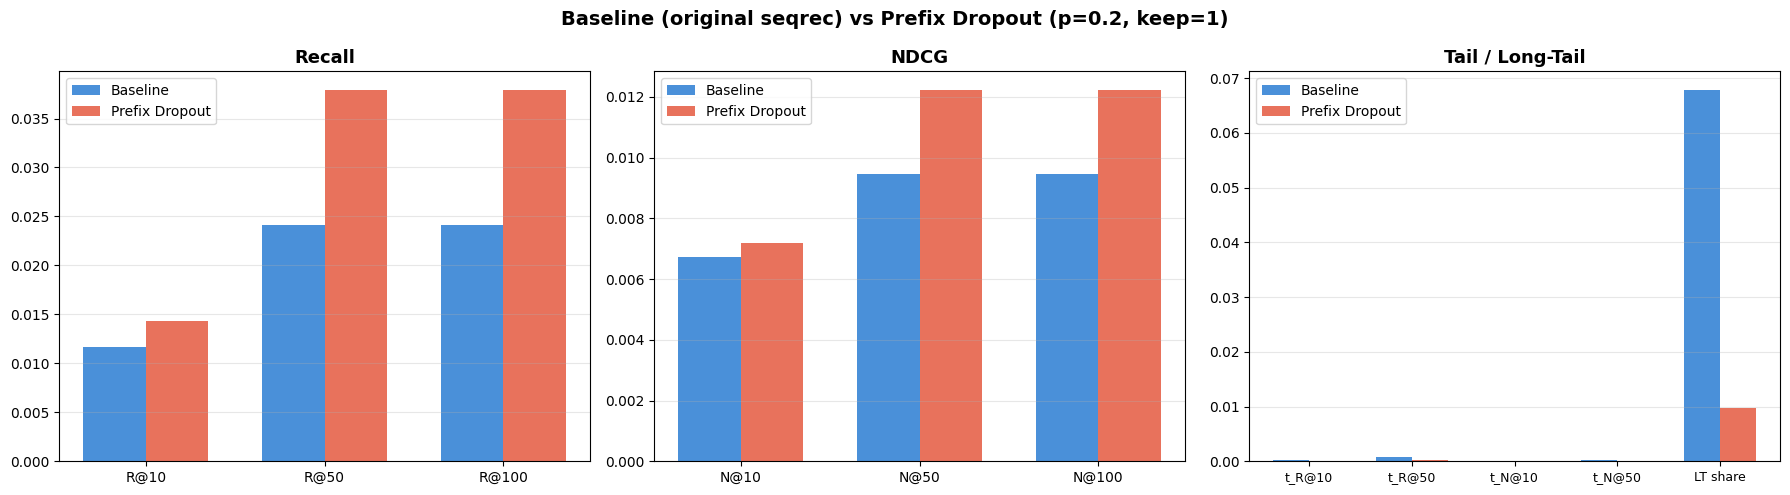

results/RQ_album_artist_anchor/prefix_dropout/comparison_plot.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLORS = {"baseline": "#4A90D9", "dropout": "#E8725C"}
w = 0.35


keys = ["recall@10", "recall@50", "recall@100"]
x = np.arange(len(keys))
axes[0].bar(x - w/2, [baseline[k] for k in keys], w, label="Baseline", color=COLORS["baseline"])
axes[0].bar(x + w/2, [dropout[k] for k in keys], w, label="Prefix Dropout", color=COLORS["dropout"])
axes[0].set_xticks(x)
axes[0].set_xticklabels([k.replace("recall", "R") for k in keys])
axes[0].set_title("Recall", fontweight="bold", fontsize=13)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)


keys = ["ndcg@10", "ndcg@50", "ndcg@100"]
axes[1].bar(x - w/2, [baseline[k] for k in keys], w, label="Baseline", color=COLORS["baseline"])
axes[1].bar(x + w/2, [dropout[k] for k in keys], w, label="Prefix Dropout", color=COLORS["dropout"])
axes[1].set_xticks(x)
axes[1].set_xticklabels([k.replace("ndcg", "N") for k in keys])
axes[1].set_title("NDCG", fontweight="bold", fontsize=13)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

keys = ["tail_recall@10", "tail_recall@50", "tail_ndcg@10", "tail_ndcg@50", "long_tail_share"]
x3 = np.arange(len(keys))
axes[2].bar(x3 - w/2, [baseline[k] for k in keys], w, label="Baseline", color=COLORS["baseline"])
axes[2].bar(x3 + w/2, [dropout[k] for k in keys], w, label="Prefix Dropout", color=COLORS["dropout"])
axes[2].set_xticks(x3)
axes[2].set_xticklabels(["t_R@10", "t_R@50", "t_N@10", "t_N@50", "LT share"], fontsize=9)
axes[2].set_title("Tail / Long-Tail", fontweight="bold", fontsize=13)
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Baseline (original seqrec) vs Prefix Dropout (p=0.2, keep=1)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

os.makedirs(RESULT_DIR, exist_ok=True)
plt.savefig(f"{RESULT_DIR}/comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{RESULT_DIR}/comparison_plot.png")

---
## 9. Выводы

In [5]:
comparison_df.to_csv(f"{RESULT_DIR}/comparison_vs_baseline.csv", index=False)
print(f"Таблица: {RESULT_DIR}/comparison_vs_baseline.csv")


tail_r10_delta = dropout.get("tail_recall@10", 0) - baseline.get("tail_recall@10", 0)
r10_delta = dropout.get("recall@10", 0) - baseline.get("recall@10", 0)


print(f"tail_recall@10:{tail_r10_delta:+.6f}")
print(f"recall@10:{r10_delta:+.6f}")



Таблица: results/RQ_album_artist_anchor/prefix_dropout/comparison_vs_baseline.csv
tail_recall@10:-0.000197
recall@10:+0.002735


---
## Интерпретация


| Метрика | Зачем | Результат | Δ (%) |
|---------|-------|-----------|-------|
| `tail_recall@10` | Качество на редких треках | 0.0002 → 0.0000 | -100% |
| `tail_recall@50` | Качество на редких треках | 0.0008 → 0.0002 | -75% |
| `long_tail_share` | Доля редких треков в рекомендациях | 0.068 → 0.010 | -85.6% |
| `recall@10` | Общее качество | 0.0116 → 0.0144 | +23.5% |
| `ndcg@10` | Общее качество | 0.0067 → 0.0072 | +6.7% |
| `head_recall@10` | Качество на популярных | 0.0158 → 0.0196 | +24.1% |
| `coverage@10` | Разнообразие | 0.0170 → 0.0125 | -26.3% |

### Вывод

Гипотеза не подтвердилась.  prefix dropout (p=0.2, keep=1) не улучшает tail-рекомендации. Вместо обобщения по семантическому префиксу модель стягивается к популярным элементам группы - теряя уникальность редких треков при обрезке SID. Общее качество (recall, NDCG) неожиданно выростает за счёт усиления head-предсказаний.

### Future work:
- Подбор p ∈ {0.05, 0.1, 0.3}: меньший дропаут может сохранить больше информации
- Подбор keep ∈ {2, 3}: оставлять больше кодов при обрезке
- Curriculum dropout: постепенно увеличивать p по ходу обучения
- Комбинация с inverse popularity weighting - усилить сигнал от редких треков
- Auxiliary loss на артиста/альбом - альтернативный способ внести семантику в SID
